In [10]:
#Conexion al dataset y carga de datos
#Para visualizar el dataset utilizado en este proyecto es posible dirigirse al siguiente link: https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

drive.mount('/content/drive')

ruta_2023_24 = '/content/drive/MyDrive/PROY INTELIGENCIA ANALITICA Y MINERIA DE DATOS/Sales 2023-24.csv'
ruta_2024_25 = '/content/drive/MyDrive/PROY INTELIGENCIA ANALITICA Y MINERIA DE DATOS/Sales 2024-25.csv'

def cargar_csv(ruta):
    try:
        return pd.read_csv(ruta, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(ruta, encoding='latin1')

df_year1 = cargar_csv(ruta_2023_24)
df_year2 = cargar_csv(ruta_2024_25)

print(f"/dataset cargado 2023-24: {df_year1.shape[0]:,} filas y {df_year1.shape[1]} columnas.")
print(f"/dataset cargado 2024-25: {df_year2.shape[0]:,} filas y {df_year2.shape[1]} columnas.")

df = pd.concat([df_year1, df_year2], axis=0, ignore_index=True)

del df_year1, df_year2
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/dataset cargado 2023-24: 525,461 filas y 8 columnas.
/dataset cargado 2024-25: 541,910 filas y 8 columnas.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2023 07:45,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2023 07:45,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2023 07:45,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2023 07:45,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2023 07:45,1.25,13085.00,United Kingdom


In [6]:
print("/resumen de tipado de datos y columnas")
print(df.info())

print("\n /estadistica del dataset")
print(df.describe())

/resumen de tipado de datos y columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None

 /estadistica del dataset
        Quantity      Price  Customer ID
count 1067371.00 1067371.00    824364.00
mean        9.94       4.65     15324.64
std       172.71     123.55      1697.46
min    -80995.00  -53594.36     12346.00
25%         1.00       1.25     13975.00
50%         3.00       2.10     15255.00
75%        10.00       4.15

In [11]:
#limpieza de datos

n_inicial = len(df)
print(f"Total registros iniciales: {n_inicial:,}")

df.columns = df.columns.str.strip()
df.rename(columns={'Invoice': 'InvoiceNo', 'Customer ID': 'CustomerID', 'Price': 'UnitPrice'}, inplace=True)

duplicados = df.duplicated().sum()
print(f"Duplicados encontrados y eliminados: {duplicados:,}")
df.drop_duplicates(inplace=True)

#eliminacion de clientes nulos debido a que para el analisis es necesario entender quien es el cliente
nulos_clientes = df['CustomerID'].isnull().sum()
print(f"Registros sin CustomerID eliminados: {nulos_clientes:,}")
df.dropna(subset=['CustomerID'], inplace=True)

#para el analisis posterior no es necesario facturas canceladas
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
cancelaciones = df['InvoiceNo'].str.upper().str.startswith('C').sum()
print(f"Facturas de cancelación (inician con 'C') eliminadas: {cancelaciones:,}")
df = df[~df['InvoiceNo'].str.upper().str.startswith('C')]

#depuracion de outliers
anomalias_qty_price = ((df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)).sum()
print(f"Registros con Quantity o UnitPrice <= 0 eliminados: {anomalias_qty_price:,}")
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['CustomerID'] = df['CustomerID'].astype(int).astype(str) # Identificador en string
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True) # Formato fecha

n_final = len(df)
eliminados = n_inicial - n_final

print("\n" + f"Registros limpios finales: {n_final:,}")
print(f"Total registros eliminados: {eliminados:,} ({(eliminados/n_inicial)*100:.2f}%)")


Total registros iniciales: 1,067,371
Duplicados encontrados y eliminados: 34,335
Registros sin CustomerID eliminados: 235,151
Facturas de cancelación (inician con 'C') eliminadas: 18,390
Registros con Quantity o UnitPrice <= 0 eliminados: 70

Registros limpios finales: 779,425
Total registros eliminados: 287,946 (26.98%)


       Quantity  UnitPrice  TotalAmount
count 779425.00  779425.00    779425.00
mean      13.49       3.22        22.29
std      145.86      29.68       227.43
min        1.00       0.00         0.00
25%        2.00       1.25         4.95
50%        6.00       1.95        12.48
75%       12.00       3.75        19.80
max    80995.00   10953.50    168469.60


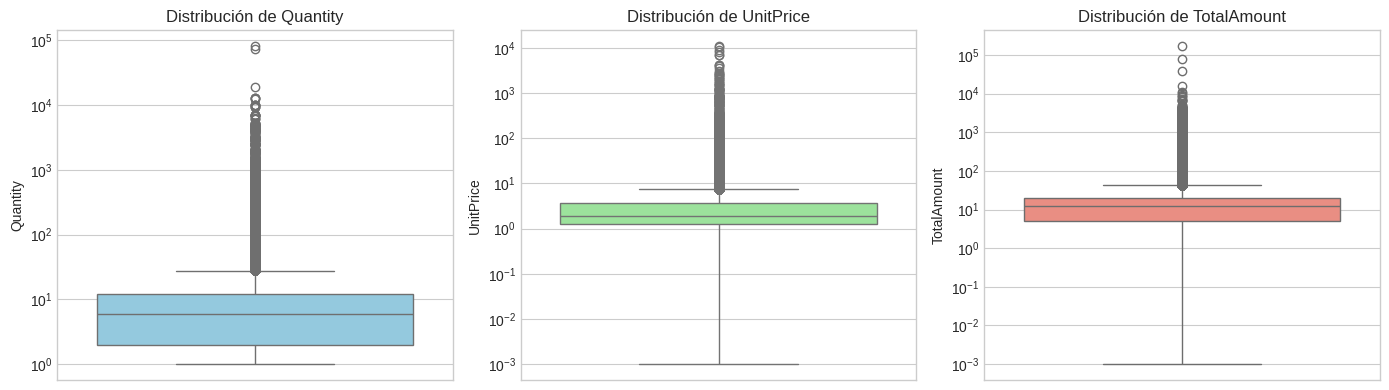

In [12]:
#creacion de variables (TotalAmount) y outliers

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(df[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

#boxplot
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Quantity'], color='skyblue')
plt.title('Distribución de Quantity')
plt.yscale('log') # Escala logarítmica para poder ver la distribución

plt.subplot(1, 3, 2)
sns.boxplot(y=df['UnitPrice'], color='lightgreen')
plt.title('Distribución de UnitPrice')
plt.yscale('log')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['TotalAmount'], color='salmon')
plt.title('Distribución de TotalAmount')
plt.yscale('log')

plt.tight_layout()
plt.show()

In [13]:
#feature enginering (rfm)

fecha_corte = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Fecha de analisis: {fecha_corte.strftime('%d/%m/%Y')}")

#agrupacion clientes
df_clientes = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (fecha_corte - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    Country=('Country', 'first')
).reset_index()

# Feature Engineering variabels
df_clientes['AvgTicket'] = df_clientes['Monetary'] / df_clientes['Frequency']

df_clientes['Is_UK'] = (df_clientes['Country'] == 'United Kingdom').astype(int)

# churn
df_clientes['Churn'] = (df_clientes['Recency'] > 90).astype(int)

print(f"Distinct de clientes analizados: {df_clientes.shape[0]:,}")
print("\n Distribución de la variable objetivo (churn)")
print(df_clientes['Churn'].value_counts(normalize=True) * 100)

df_clientes.head()

Fecha de analisis: 10/12/2025
Distinct de clientes analizados: 5,878

 Distribución de la variable objetivo (churn)
Churn
1   50.85
0   49.15
Name: proportion, dtype: float64


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,Country,AvgTicket,Is_UK,Churn
0,12346,326,12,77556.46,74285,United Kingdom,6463.04,1,1
1,12347,2,8,4921.53,2967,Iceland,615.19,0,0
2,12348,75,5,2019.40,2714,Finland,403.88,0,0
3,12349,19,4,4428.69,1624,Italy,1107.17,0,0
4,12350,310,1,334.40,197,Norway,334.40,0,1


In [14]:
#division del dataset (train, val, test)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#variables predictoras (X) y variable objetivo (y)
features = ['Frequency', 'Monetary', 'TotalQuantity', 'AvgTicket', 'Is_UK']
X = df_clientes[features]
y = df_clientes['Churn']

#partición: 70% Train, 30% Temporal (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

#partición: dividimos el 30% en dos partes iguales (15% Val y 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

#escalamiento de variables con StandardScaler
scaler = StandardScaler()
# evitacion de contaminacion train
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#dataset convertido
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print(f"Conjunto de Entrenamiento (Train 70%): {X_train.shape[0]} registros")
print(f"Conjunto de Validación   (Val 15%):   {X_val.shape[0]} registros")
print(f"Conjunto de Prueba        (Test 15%):  {X_test.shape[0]} registros")

X_train_scaled.head()

Conjunto de Entrenamiento (Train 70%): 4114 registros
Conjunto de Validación   (Val 15%):   882 registros
Conjunto de Prueba        (Test 15%):  882 registros


,Frequency,Monetary,TotalQuantity,AvgTicket,Is_UK
0,-0.39,-0.19,-0.22,-0.11,0.32
1,1.44,0.32,0.53,-0.07,0.32
2,-0.39,-0.19,-0.24,-0.08,0.32
3,0.22,-0.12,-0.14,-0.18,0.32
4,-0.39,-0.20,-0.24,-0.23,0.32


In [15]:
#entrenamiento y comparacion de modelos de clasificacion
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modelo_lr = LogisticRegression(random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

#entramiento con el modelo training
modelo_lr.fit(X_train_scaled, y_train)
modelo_rf.fit(X_train, y_train) # Random Forest no requiere escalamiento estricto, usa X_train directamente

def calcular_metricas(modelo, X, y, escalado=False):
    y_pred = modelo.predict(X)
    y_prob = modelo.predict_proba(X)[:, 1]
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'AUC-ROC': roc_auc_score(y, y_prob)
    }

metricas_lr_val = calcular_metricas(modelo_lr, X_val_scaled, y_val)
metricas_rf_val = calcular_metricas(modelo_rf, X_val, y_val)

df_comparativa = pd.DataFrame([metricas_lr_val, metricas_rf_val], index=['Logistic Regression', 'Random Forest'])
print("comparativa tecnica")
print(df_comparativa.round(4))

comparativa tecnica
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression      0.69       0.66    0.78      0.72     0.75
Random Forest            0.69       0.69    0.71      0.70     0.76


reporte tecnico detallado en prueba (test)
              precision    recall  f1-score   support

  Activo (0)     0.7238    0.6536    0.6869       433
   Churn (1)     0.6945    0.7595    0.7255       449

    accuracy                         0.7075       882
   macro avg     0.7091    0.7065    0.7062       882
weighted avg     0.7089    0.7075    0.7066       882



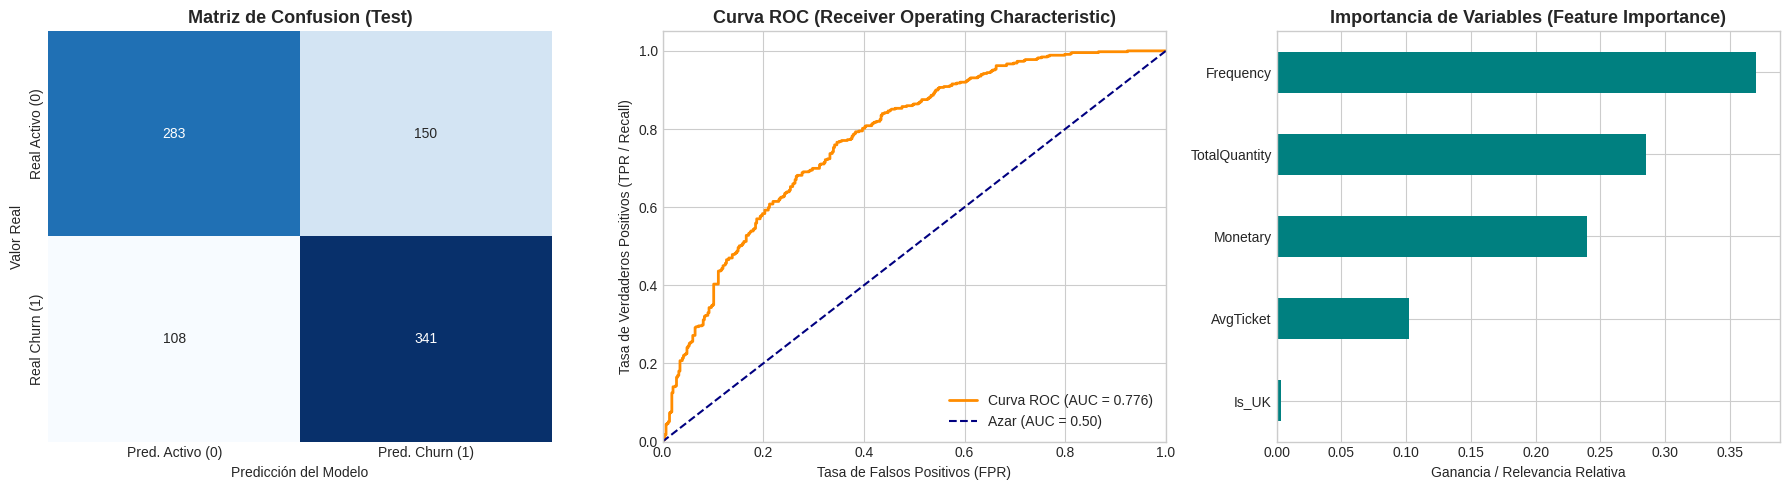

In [16]:
#evaluacion en test y visualizaciones obligatorias del aca
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

#predicciones conjunto de prueba no visto (Test)
y_pred_test = modelo_rf.predict(X_test)
y_prob_test = modelo_rf.predict_proba(X_test)[:, 1]

print("reporte tecnico detallado en prueba (test)")
print(classification_report(y_test, y_pred_test, target_names=['Activo (0)', 'Churn (1)'], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred. Activo (0)', 'Pred. Churn (1)'],
            yticklabels=['Real Activo (0)', 'Real Churn (1)'])
axes[0].set_title('Matriz de Confusion (Test)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción del Modelo')

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Azar (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[1].set_title('Curva ROC (Receiver Operating Characteristic)', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right")

# Importancia de Variables (Feature Importance)
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=True)
importancias.plot(kind='barh', color='teal', ax=axes[2])
axes[2].set_title('Importancia de Variables (Feature Importance)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Ganancia / Relevancia Relativa')

plt.tight_layout()
plt.show()

Total de semanas: 106
Rango de fechas: 03/12/2023 a 07/12/2025

 test de dickey fuller aumentado (ADF)
Estadístico ADF: -3.8025
p-valor: 0.0029
conclusion: La serie es Estacionaria (p <= 0.05).


/tmp/ipykernel_2149/3123200576.py:19: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test = adfuller(serie_ventas)


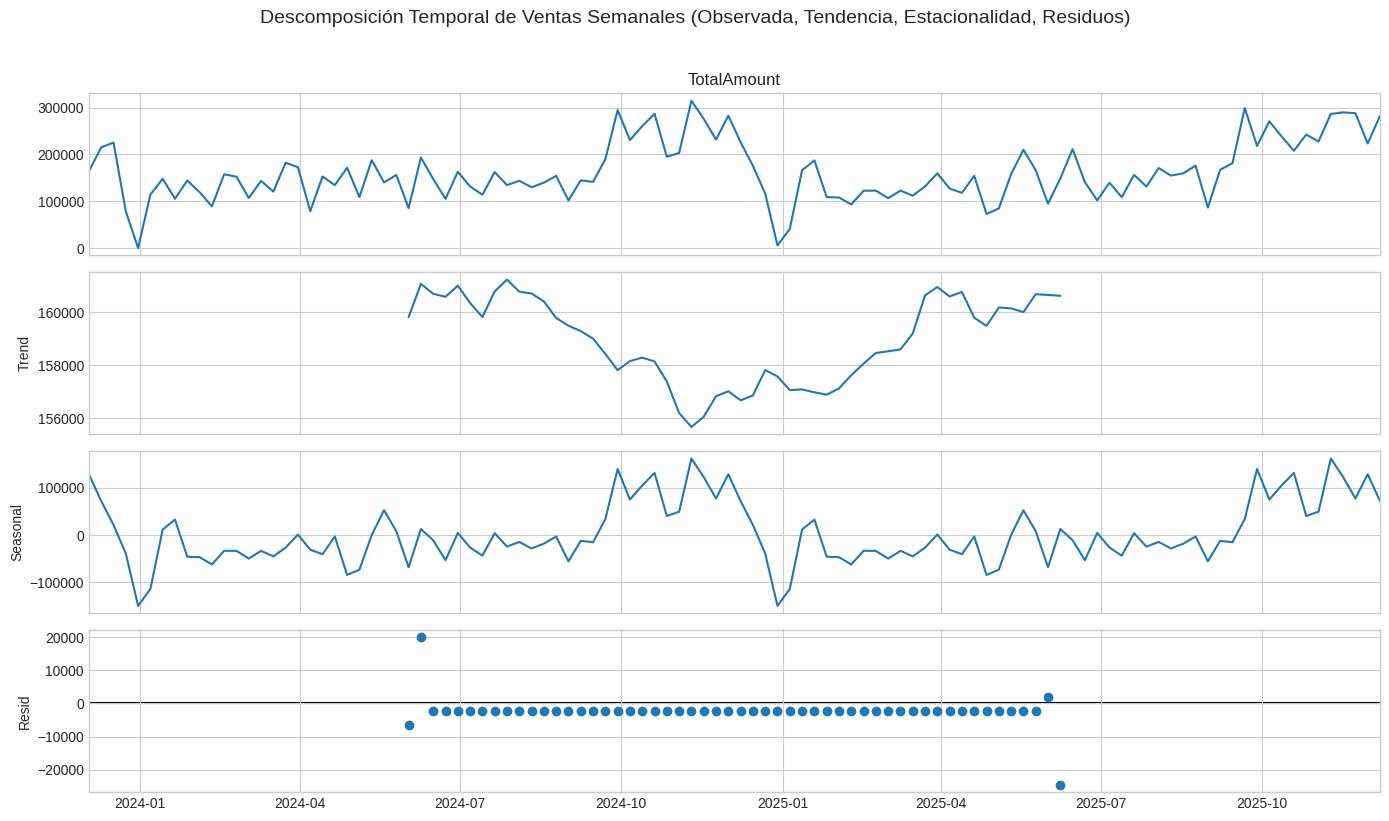

In [17]:
#contruccion de un dataset temporal y descomposicion estacional para el analisis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

df_temp = df[['InvoiceDate', 'TotalAmount']].copy()
df_temp.set_index('InvoiceDate', inplace=True)

#resampling a frecuencia semanal ('W'), sumando el total vendido por semana
serie_ventas = df_temp['TotalAmount'].resample('W').sum()

#eliminar las semana final en caso de no estar completa
if len(serie_ventas) > 100:
    serie_ventas = serie_ventas[:-1]

print(f"Total de semanas: {len(serie_ventas)}")
print(f"Rango de fechas: {serie_ventas.index.min().strftime('%d/%m/%Y')} a {serie_ventas.index.max().strftime('%d/%m/%Y')}")

#Test de Estacionariedad (Dickey-Fuller Aumentado - ADF)
adf_test = adfuller(serie_ventas)
print("\n test de dickey fuller aumentado (ADF)")
print(f"Estadístico ADF: {adf_test[0]:.4f}")
print(f"p-valor: {adf_test[1]:.4f}")
if adf_test[1] <= 0.05:
    print("conclusion: La serie es Estacionaria (p <= 0.05).")
else:
    print("conclusión: La serie NO es estacionaria (p > 0.05). Requiere diferenciación.")

#descomposición de la serie: Tendencia, Estacionalidad y Residuo (visualización obligatoria)
descomposicion = seasonal_decompose(serie_ventas, model='additive', period=52) # periodo 52 semanas (1 año)

fig = descomposicion.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Descomposición Temporal de Ventas Semanales (Observada, Tendencia, Estacionalidad, Residuos)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Semanas de Entrenamiento (Train): 94
Semanas de Prueba (Test Horizon): 12
evaluacion tecnica del pronostico (test)
MAE  (Error Absoluto Medio):           £97,475.40
RMSE (Raíz del Error Cuadrático Medio): £102,334.47
MAPE (Error Porcentual Absoluto Medio): 37.07%


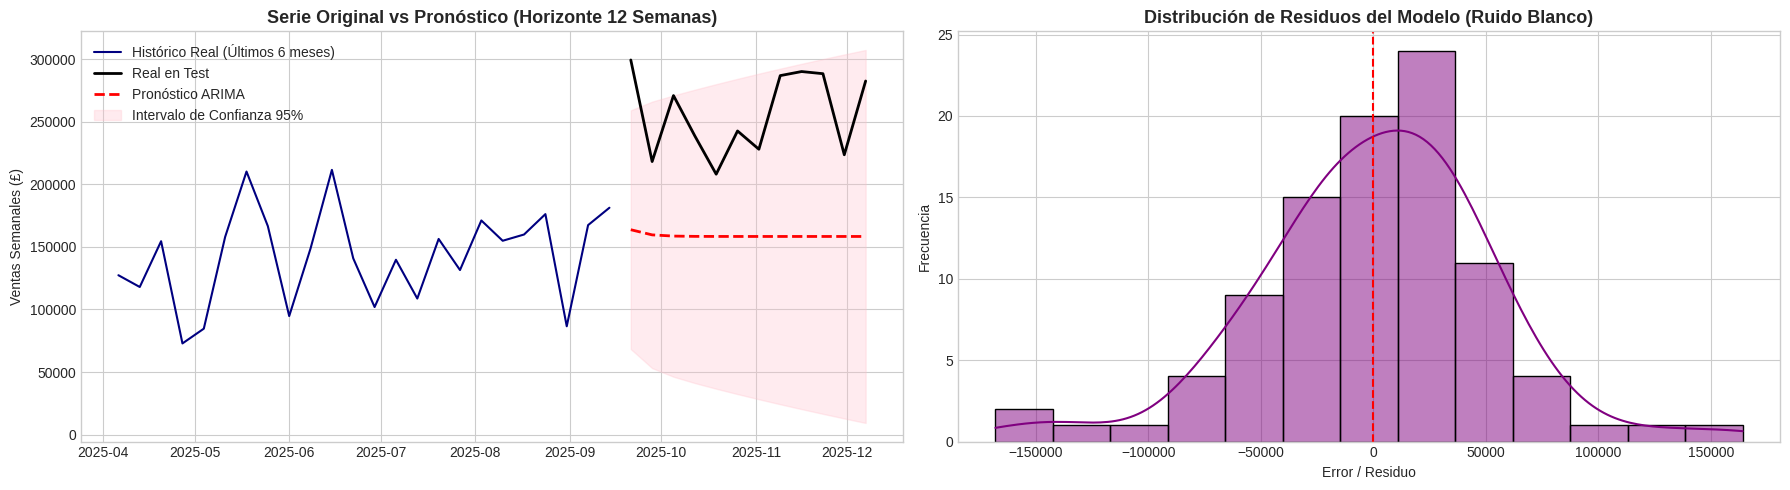

In [18]:
#modelo de series de tiempo (arima/sarima)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy.stats as stats

#division temporal: Train (histórico) y Test (últimas 12 semanas para pronosticar)
n_test = 12
train_ts = serie_ventas[:-n_test]
test_ts = serie_ventas[-n_test:]

print(f"Semanas de Entrenamiento (Train): {len(train_ts)}")
print(f"Semanas de Prueba (Test Horizon): {len(test_ts)}")

#Modelo ARIMA(1, 1, 1)
# Utiliza 1 autoregresivo, 1 diferenciación y 1 media móvil
modelo_arima = SARIMAX(train_ts, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
resultado_arima = modelo_arima.fit(disp=False)

#forecasting para test
predicciones_obj = resultado_arima.get_forecast(steps=n_test)
predicciones_ts = predicciones_obj.predicted_mean
intervalo_confianza = predicciones_obj.conf_int()

mae = mean_absolute_error(test_ts, predicciones_ts)
rmse = np.sqrt(mean_squared_error(test_ts, predicciones_ts))
mape = np.mean(np.abs((test_ts - predicciones_ts) / test_ts)) * 100

print("evaluacion tecnica del pronostico (test)")
print(f"MAE  (Error Absoluto Medio):           £{mae:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): £{rmse:,.2f}")
print(f"MAPE (Error Porcentual Absoluto Medio): {mape:.2f}%")

# Serie Original vs Pronóstico y Diagnóstico de Residuos (visualizacion obligatoria)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Serie Original vs Pronóstico con Intervalos de Confianza al 95%
axes[0].plot(train_ts.index[-24:], train_ts[-24:], label='Histórico Real (Últimos 6 meses)', color='navy')
axes[0].plot(test_ts.index, test_ts, label='Real en Test', color='black', lw=2)
axes[0].plot(test_ts.index, predicciones_ts, label='Pronóstico ARIMA', color='red', linestyle='--', lw=2)
axes[0].fill_between(test_ts.index,
                     intervalo_confianza.iloc[:, 0],
                     intervalo_confianza.iloc[:, 1],
                     color='pink', alpha=0.3, label='Intervalo de Confianza 95%')
axes[0].set_title('Serie Original vs Pronóstico (Horizonte 12 Semanas)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ventas Semanales (£)')
axes[0].legend(loc='upper left')

# Diagnóstico de Residuos (Distribución y Normalidad)
residuos = resultado_arima.resid
sns.histplot(residuos, kde=True, color='purple', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de Residuos del Modelo (Ruido Blanco)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Error / Residuo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()